# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание. Нейронные сети

### Общая информация

Дата выдачи: 24.03.2026

Мягкий дедлайн: 14.04.2026 23:59

Жесткий дедлайн: 19.04.2026 23:59

### О задании

В этой работе две независимые части:

- Часть 1. Separable Physics-Informed Neural Network (SPINN) для решения 3D-уравнения Гельмгольца - 4 балла.

- Часть 2. CNN-классификация звуков на датасете UrbanSound8K - 6 баллов.

### Оценивание

Максимально допустимая оценка за работу - 10 баллов. 4 балла за SPINN и 6 баллов за CNN.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке. Оценка также может быть снижена за плохо читаемый код и плохо оформленные диаграммы/таблицы. Изменять проверочные ячейки и пороги `assert` запрещено.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.

### Про вычислительные ресурсы

Задание рассчитано на выполнение в бесплатном Google Colab или Kaggle Notebook, если реализация сделана разумно.

- Используйте GPU экономно: черновую отладку, проверку кода и подготовку пайплайна лучше сначала выполнять на CPU, а GPU подключать уже для обучения и финальных экспериментов. Это поможет избежать лишних проблем с памятью и не тратить ресурсы впустую.
- Для SPINN обучение должно занимать умеренное время; если одна конфигурация обучается слишком долго, стоит проверить размер модели, число коллокационных точек и эффективность реализации.
- Для UrbanSound8K рекомендуется предвычислять спектрограммы и сохранять их на диск. Без этого эксперименты часто упираются в CPU-препроцессинг, а не в обучение модели.
- Для подбора гиперпараметров разумно сначала работать на одном фиксированном dev-split, а полный 10-fold cross-validation запускать только для финальной модели.
- При обучении свёрточных сетей может помочь `torch.backends.cudnn.benchmark = True`.

### Формат сдачи

Задания сдаются через систему Anytask. Необходимо прислать ноутбук с выполненным заданием; к ноутбуку прикрепите два файла с весами лучших моделей для каждой из двух задач: `best_spinn_model.pth` и `best_cnn_model.pth`. Сам ноутбук называйте в формате `homework-practice-04-dl-Username.ipynb`, где Username - ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку, исходя из набора выполненных задач и достигнутого качества, и укажите её ниже.

Оценка: ...






In [33]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import librosa
import librosa.display
from IPython.display import Audio

In [34]:
random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Часть 1. SPINN для 3D-уравнения Гельмгольца (4 балла)


### Разбалловка

Для удобства разбалловка задания представлена в таблице ниже. В первой части основное внимание уделяется корректной реализации SPINN-архитектуры, организации обучения и анализу результатов.

| Подзадача | Баллы | Что оценивается |
|-----------|-------|-----------------|
| 1.1 Реализация separable-архитектуры | **2,0** | Реализация класса `BaseSPINN`: три body-сети, корректная separable-сборка решения на решётке и на произвольных точках, согласованность с `BaseModel` |
| 1.2 Обучение и качество | **1,5** | Модель сходится, обучение организовано корректно, результат воспроизводим, достигнуто разумное качество на тестовой сетке |
| 1.3 Анализ экспериментов | **0,5** | Краткий разбор выбранной конфигурации и наблюдений по качеству и скорости


### Что такое PINN

**Physics-Informed Neural Networks (PINNs)** - это нейросетевые модели, которые используют для обучения не только данные, но и структуру самой физической задачи.

Идея состоит в том, что модель должна не просто приближать неизвестную функцию, а строить решение, которое согласовано с заданным дифференциальным уравнением и граничными условиями.

В отличие от стандартной постановки supervised learning, где у нас есть множество пар "вход-ответ", в PINN функция потерь обычно включает две части:

- PDE loss - это невязка дифференциального уравнения внутри области;
- BC loss - это ошибка на границе области, где известны граничные условия.

Благодаря этому PINN можно применять даже в ситуациях, когда наблюдений мало, но сама структура задачи хорошо известна.

Физика - ммм, уже испугались?)

> На деле, глубоко разбираться в физике здесь не требуется. Вся постановка задачи первой части - уравнение, точное решение, функция источника и граничные условия - уже реализована в `BaseModel`.

Для выполнения задания достаточно понимать следующее:

- есть неизвестная функция $u(x, y, z)$, которую нужно приблизить нейросетью;
- внутри области решение должно удовлетворять дифференциальному уравнению (PDE loss);
- на границе куба решение должно обращаться в ноль (BC loss);
- точное решение нам известно, поэтому мы можем измерять ошибку модели после обучения.

**Ваша задача - реализовать архитектуру SPINN**, а не выводить физические формулы с нуля.

> *SPINN - чего?* 😧

### Что такое SPINN

**SPINN (Separable Physics-Informed Neural Network)** - это архитектурная модификация PINN для многомерных задач.  

[Статья: *Separable Physics-Informed Neural Networks*, NeurIPS 2023](https://arxiv.org/abs/2306.15969)

В обычном PINN одна большая сеть получает на вход сразу точку $(x, y, z)$ и предсказывает значение функции $u(x, y, z)$.

В SPINN идея другая: вместо одной общей сети используются несколько небольших сетей - по одной на каждую координату.  

Для нашей 3D-задачи это означает:

- первая сеть обрабатывает только $x$;
- вторая сеть обрабатывает только $y$;
- третья сеть обрабатывает только $z$.

Каждая из этих сетей возвращает вектор длины `rank`, а итоговое решение собирается через CP-подобное объединение:

$$
u[i, j, k] = \sum_{r=1}^{\text{rank}} f_x[i, r] \cdot f_y[j, r] \cdot f_z[k, r].
$$

Интуитивно это похоже на CP-декомпозицию ([Canonical Polyadic decomposition](https://en.wikipedia.org/wiki/Tensor_rank_decomposition#:~:text=clarification%20needed%5D-,Canonical%20polyadic%20decomposition%20(CPD),-is%20a%20variant)), где трёхмерный тензор представляется как сумма тензоров ранга 1:

$$
\hat{u} = \sum_{r=1}^{R} \mathbf{f}_r^{(x)} \otimes \mathbf{f}_r^{(y)} \otimes \mathbf{f}_r^{(z)}.
$$

Главная идея здесь в том, что на tensor-product grid можно отдельно обработать оси, а затем собрать итоговый тензор решения. Именно поэтому SPINN особенно удобен для многомерных PDE-задач, где pointwise-подход быстро становится вычислительно дорогим.

> В этой домашней работе мы используем **учебную реализацию ключевой идеи SPINN**: separable body-сети + CP-merge. Вам не нужно воспроизводить все технические детали статьи; важно корректно реализовать архитектуру и получить рабочее решение.
>
> Но если вам захочется погрузиться в задачу максимально - препятствовать не будем, скорее замолвим за вас словечко в [LAMBDA](https://cs.hse.ru/iai/lambda/).

### Уравнение Гельмгольца

В задаче рассматривается 3D-уравнение Гельмгольца:

$$
\nabla^2 u + k^2 u = q(x,y,z), \quad (x,y,z) \in [-1,1]^3, \quad u\big|_{\text{граница}} = 0.
$$

Здесь:

- $u(x,y,z)$ - неизвестная функция;
- $k$ - волновое число;
- $q(x,y,z)$ - правая часть (источник);
- на границе области заданы нулевые граничные условия Дирихле.

Для тестирования используется точное решение:

$$
u(x,y,z) = \sin(\pi x)\sin(\pi y)\sin(\pi z).
$$

На всех шести гранях куба $\Omega = [-1,1]^3$ задаются нулевые граничные условия:

$$
u(x,y,z) = 0, \quad (x,y,z) \in \partial \Omega.
$$

### Описание задания

В этой части вам нужно:

1. реализовать три независимые body-сети —- по одной для каждой координаты;
2. получить из них separable-представление решения;
3. корректно объединить выходы через CP-merge;
4. реализовать вычисление модели на решётке и на произвольных точках;
5. обучить модель, оценить качество решения на тестовой сетке и проанализировать результаты.

Несколько вспомогательных функций для точного решения, оценки ошибки и визуализации:

In [35]:
def helmholtz3d_exact_u(a1, a2, a3, x, y, z):
    """a1, a2, a3 -- это константы, x,y,z - это сетка-тензор из мешгрида --> вычисление реальной функции"""
    return (
        torch.sin(a1 * torch.pi * x)
        * torch.sin(a2 * torch.pi * y)
        * torch.sin(a3 * torch.pi * z)
    )


def relative_l2(u_pred, u_true):
    """Относительная L2-ошибка: ||u_pred - u_true|| / ||u_true||"""
    return torch.linalg.norm(u_pred - u_true) / torch.linalg.norm(u_true)

А тут вспомогательные функции для визуализации и оценки: код уже готов и нужен вам как инфраструктура для экспериментов. Он помогает визуализировать решение, отслеживать динамику loss'ов, считать ошибку на тестовой сетке и пересэмплировать коллокационные точки.

In [36]:
def plot_helmholtz3d(x, y, z, u):
    """x,y,z снова из мешгрида, а u значение функции на этих точках --> это визуализация решения PDE в 3D"""
    x = x.detach().cpu().numpy().flatten()
    y = y.detach().cpu().numpy().flatten()
    z = z.detach().cpu().numpy().flatten()
    u = u.detach().cpu().numpy().flatten()

    u_norm = (u - u.min()) / (u.max() - u.min() + 1e-10)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        x, y, z,
        c=u_norm,
        s=1,
        cmap="seismic",
        vmin=0,
        vmax=1,
        alpha=0.75,
        edgecolors="none",
    )

    ax.set_title("U(x, y, z)", fontsize=18)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    cbar = plt.colorbar(scatter, shrink=0.8, aspect=15)
    cbar.set_label("u(x,y,z)")

    plt.tight_layout()
    plt.show()


def plot_losses(
    loss_history,
    residual_history,
    boundary_history,
    error_history,
    log_iter,
    title_prefix="",
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.semilogy(loss_history, label="Total Loss", linewidth=2)
    ax1.semilogy(residual_history, label="PDE Loss", alpha=0.7)
    ax1.semilogy(boundary_history, label="BC Loss", alpha=0.7)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss (log scale)")
    ax1.set_title(f"{title_prefix}Training Losses")

    iterations = np.arange(0, len(error_history) * log_iter, log_iter)
    ax2.semilogy(iterations, error_history, "r-", linewidth=2, label="Relative L2 Error")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Error (log scale)")
    ax2.set_title(f"{title_prefix}Relative L2 Error")

    plt.tight_layout()
    plt.show()


def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):
    """
    Вычисление ошибки модели на фиксированной сетке.


    """

    was_training = model.training
    model.eval()

    with torch.no_grad():
        coords = torch.stack(
            [x_grid.flatten(), y_grid.flatten(), z_grid.flatten()],
            dim=1,
        )
        u_pred = model(coords)
        error = relative_l2(u_pred, u_true.flatten())

    if was_training:
        model.train()

    return error, u_pred.reshape(x_grid.shape)


def resample_collocation_points(model, NC, domain_size=1.0):
    """
    Ресэмплирование коллокационных точек на кубической решётке.
    """

    N_per_axis = int(round(NC ** (1 / 3)))

    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=model.device)

    xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")

    xc = xx.flatten().requires_grad_(True)
    yc = yy.flatten().requires_grad_(True)
    zc = zz.flatten().requires_grad_(True)

    return xc, yc, zc

Глянем на визуальзацию точного решения на тестовой сетке.

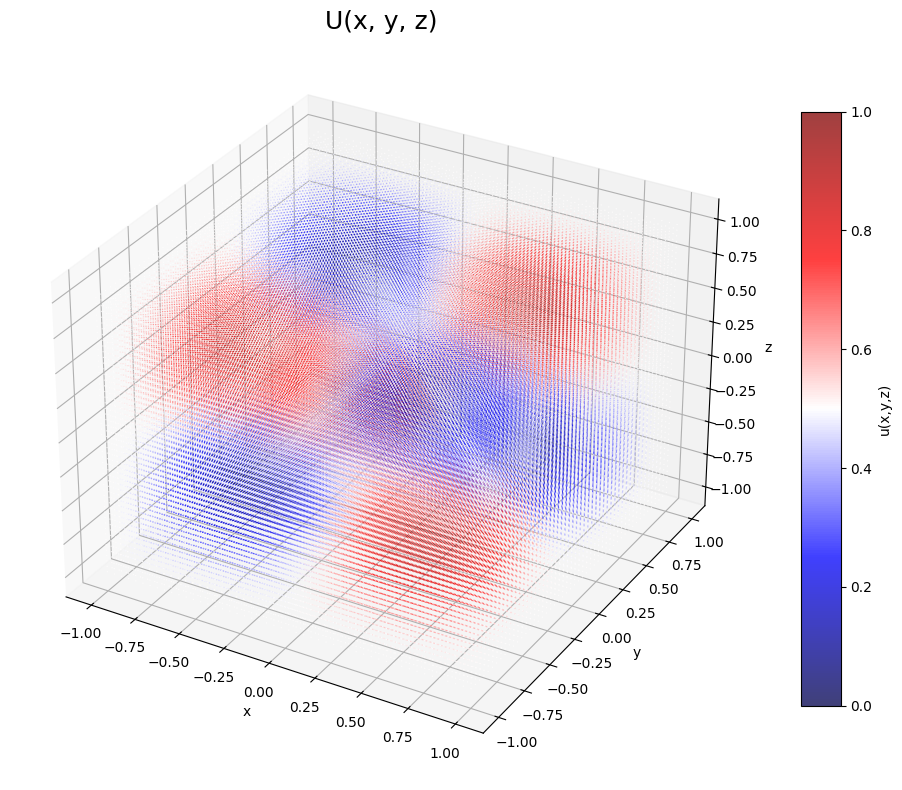

In [37]:
N_test = 50

x_test = torch.linspace(-1, 1, N_test, device=device)
y_test = torch.linspace(-1, 1, N_test, device=device)
z_test = torch.linspace(-1, 1, N_test, device=device)

xx_test, yy_test, zz_test = torch.meshgrid(x_test, y_test, z_test, indexing="ij")
u_test = helmholtz3d_exact_u(1, 1, 1, xx_test, yy_test, zz_test)

plot_helmholtz3d(xx_test, yy_test, zz_test, u_test)

### Задание 1.1. Реализуйте SPINN-архитектуру (2 балла)

В этом пункте нужно реализовать дочерний класс от `BaseModel`, который задаёт Separable Physics-Informed Neural Network для трёхмерного уравнения Гельмгольца.

Идея остаётся той же, что и в [статье](https://arxiv.org/pdf/2306.15969): вместо одной сети, работающей сразу с тройкой координат, используется три независимые body-сети - для $x$, $y$ и $z$. Их выходы затем объединяются в separable-представление решения

$$
u(x,y,z)=\sum_{j=1}^r f_j^{(1)}(x)\,f_j^{(2)}(y)\,f_j^{(3)}(z).
$$

Базовый класс уже содержит всю постановку задачи: точное решение, правую часть уравнения, граничные условия, вычисление `PDE loss` и `BC loss`. Менять его не нужно. Ваша часть работы - архитектура.

Что именно требуется:
- собрать класс `BaseSPINN`;
- реализовать три независимые body-сети;
- определить, как из их выходов получается решение на полной решётке;
- отдельно продумать, как считать модель на произвольном наборе точек, когда координаты уже не образуют декартово произведение.

Здесь важно не просто получить рабочий код, а аккуратно разобраться в размерностях. От того, какие формы имеют выходы body-сетей, зависит и корректность `forward`, и вычисление PDE loss.

После реализации сделайте короткую sanity check-проверку:
- создайте маленькую модель;
- проверьте формы выходов body-сетей;
- убедитесь, что на решётке получается тензор формы `(Nx, Ny, Nz)`;
- отдельно проверьте вычисление на наборе произвольных точек.

In [38]:
# здесь ничего не меняем - изучаем, переиспользуем

class BaseModel(nn.Module):
    """
    Базовый класс для 3D-уравнения Гельмгольца на кубе [-1, 1]^3.

    Здесь уже реализованы:
    - точное решение и правая часть PDE;
    - граничные точки на 6 гранях куба;
    - вычисление PDE loss и BC loss.

    В этом задании предполагается, что студент реализует только
    архитектурную часть в наследнике BaseSPINN.
    """

    def __init__(
        self,
        x_min: float = -1.0,
        x_max: float = 1.0,
        y_min: float = -1.0,
        y_max: float = 1.0,
        z_min: float = -1.0,
        z_max: float = 1.0,
        k: float = 1.0,
        a1: int = 1,
        a2: int = 1,
        a3: int = 1,
        N_bc: int = 32,
        device: torch.device = None,
    ):
        """Вводим начальные коэф. для уравнения и параметры куба."""
        super().__init__()
        self.x_min, self.x_max = x_min, x_max
        self.y_min, self.y_max = y_min, y_max
        self.z_min, self.z_max = z_min, z_max
        self.N_bc = N_bc
        self.k = k
        self.a1, self.a2, self.a3 = a1, a2, a3
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.mse = nn.MSELoss(reduction="mean")
        self._init_boundary_points()

    def _init_boundary_points(self):
        """Считаем точки на границе куба и потом будет штрафовать если модель не ноль на границе."""
        N = self.N_bc
        lin_x = torch.linspace(self.x_min, self.x_max, N)
        lin_y = torch.linspace(self.y_min, self.y_max, N)
        lin_z = torch.linspace(self.z_min, self.z_max, N)

        faces = []

        for x_val in [self.x_min, self.x_max]:
            yy, zz = torch.meshgrid(lin_y, lin_z, indexing="ij")
            xx = torch.full_like(yy, x_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for y_val in [self.y_min, self.y_max]:
            xx, zz = torch.meshgrid(lin_x, lin_z, indexing="ij")
            yy = torch.full_like(xx, y_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for z_val in [self.z_min, self.z_max]:
            xx, yy = torch.meshgrid(lin_x, lin_y, indexing="ij")
            zz = torch.full_like(xx, z_val)
            faces.append(torch.stack([xx.reshape(-1), yy.reshape(-1), zz.reshape(-1)], dim=1))

        for i, coords in enumerate(faces, 1):
            self.register_buffer(f"coords_bc{i}", coords.to(self.device))
            self.register_buffer(
                f"zeros_bc{i}",
                torch.zeros(coords.shape[0], 1, device=self.device)
            )

    def reference_solution(self, x, y, z):
        """Точное решение. Используется только для оценки ошибки.
           Тут x y z -- это тензоры из мешгрида, по факту мы уже писали эту функцию.
        """
        return (
            torch.sin(self.a1 * np.pi * x)
            * torch.sin(self.a2 * np.pi * y)
            * torch.sin(self.a3 * np.pi * z)
        )

    def function_of_source(self, x, y, z):
        """Правая часть PDE, полученная подстановкой точного решения.
           Тут x y z -- это тензоры из мешгрида.

        """
        u = self.reference_solution(x, y, z)
        lap_coef = -(self.a1 * np.pi) ** 2 - (self.a2 * np.pi) ** 2 - (self.a3 * np.pi) ** 2
        return (lap_coef + self.k**2) * u

    def get_body_outputs(self, x, y, z):
        """
        Должен быть реализован в наследнике.

        Ожидаемые формы:
        - x: (Nx,), y: (Ny,), z: (Nz,)
        - f_x: (Nx, rank), f_y: (Ny, rank), f_z: (Nz, rank)
        """
        raise NotImplementedError

    def forward(self, x, y, z):
        """
        Значения решения на полной декартовой решётке.


        """
        raise NotImplementedError

    def forward_pointwise(self, coords):
        """
        Значения решения на произвольном наборе точек coords формы (B, 3).


        """
        raise NotImplementedError

    @staticmethod
    def _body_second_deriv(f, inp):
        """
        Вторая производная по одной координате для каждого канала ранга.
        Предполагается, что f.shape == (N, rank), inp.shape == (N,).



        """
        _, rank = f.shape
        d2 = torch.zeros_like(f)

        for r in range(rank):
            d1 = torch.autograd.grad(f[:, r].sum(), inp, create_graph=True)[0]
            d2[:, r] = torch.autograd.grad(d1.sum(), inp, create_graph=True)[0]

        return d2

    def calculate_pde_loss(self, x_col, y_col, z_col):
        """
        PDE loss на коллокационной решётке.



        """
        x = x_col.clone().detach().requires_grad_(True)
        y = y_col.clone().detach().requires_grad_(True)
        z = z_col.clone().detach().requires_grad_(True)

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        f_x_d2 = self._body_second_deriv(f_x, x)
        f_y_d2 = self._body_second_deriv(f_y, y)
        f_z_d2 = self._body_second_deriv(f_z, z)

        u = self.forward(x, y, z)

        lap = (
            torch.einsum("ir,jr,kr->ijk", f_x_d2, f_y, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y_d2, f_z)
            + torch.einsum("ir,jr,kr->ijk", f_x, f_y, f_z_d2)
        )

        xx, yy, zz = torch.meshgrid(x, y, z, indexing="ij")
        q = self.function_of_source(xx, yy, zz)

        residual = lap + self.k**2 * u - q
        return self.mse(residual, torch.zeros_like(residual))

    def calculate_bc_loss(self):
        """
        MSE на шести гранях куба.
        """
        loss = torch.tensor(0.0, device=self.device)

        for i in range(1, 7):
            coords = getattr(self, f"coords_bc{i}")
            zeros = getattr(self, f"zeros_bc{i}")
            u_bc = self.forward_pointwise(coords).unsqueeze(-1)
            loss = loss + self.mse(u_bc, zeros)

        return loss

    def calculate_loss(self, x_col, y_col, z_col):
        loss_pde = self.calculate_pde_loss(x_col, y_col, z_col)
        loss_bc = self.calculate_bc_loss()
        return loss_pde, loss_bc

Теперь реализуйте класс `BaseSPINN`.

В этом пункте сигнатуры методов не даны заранее. Вам нужно самостоятельно восстановить архитектуру класса, согласовав её с тем, как устроен `BaseModel`, как вычисляется `PDE loss`, и как далее используется модель в обучении.

Вам нужно самостоятельно продумать:
- как устроена одна body-сеть;
- какие именно модули удобно использовать для её сборки;
- как объединять выходы трёх ветвей на полной решётке;
- чем вычисление на решётке отличается от вычисления в отдельных точках.

Перед обучением имеет смысл убедиться, что ваша реализация согласована с остальным кодом ноутбука и возвращает тензоры ожидаемых размерностей.


In [39]:
class BaseSPINN(BaseModel):
    """
    Separable PINN для 3D-задачи.

    Нужно реализовать:
    - __init__
    - _make_body_net
    - get_body_outputs
    - forward
    - forward_pointwise
    """
    def __init__(self, rank, hidden_dim, n_hidden_layers, N_bc, **kwargs):
        super().__init__(N_bc=N_bc, **kwargs)

        self.rank = rank
        self.hidden_dim = hidden_dim
        self.n_hidden_layers = n_hidden_layers

        self.net_X = self._make_body_net()
        self.net_Y = self._make_body_net()
        self.net_Z = self._make_body_net()



    def _make_body_net(self):
        layers = []
        layers.append(nn.Linear(1, self.hidden_dim))
        layers.append(nn.Tanh())

        for i in range(self.n_hidden_layers):
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(self.hidden_dim, self.rank))

        return nn.Sequential(*layers)


    def get_body_outputs(self, x, y, z):
        """
        Ожидаемые формы:
        - x: (Nx,), y: (Ny,), z: (Nz,)
        - f_x: (Nx, rank), f_y: (Ny, rank), f_z: (Nz, rank)
        """


        x = x.unsqueeze(-1)  # (Nx,) -> (Nx, 1)
        y = y.unsqueeze(-1)  # (Ny,) -> (Ny, 1)
        z = z.unsqueeze(-1)  # (Nz,) -> (Nz, 1)

        f_x = self.net_X(x)
        f_y = self.net_Y(y)
        f_z = self.net_Z(z)
        return f_x, f_y, f_z


    def forward(self, x, y, z):
        """
        Значения решения на полной декартовой решётке.
        просто вычисляем тензор U с помощью канонического разложения.
        x: (Nx, ), y: (Ny,), z: (Nz,)
        """

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)
        return torch.einsum('ir,jr,kr->ijk', f_x, f_y, f_z)


    def forward_pointwise(self, coords):
        """
        Значения решения на произвольном наборе точек coords формы (B, 3)
        """
        x = coords[:, 0]
        y = coords[:, 1]
        z = coords[:, 2]

        f_x, f_y, f_z = self.get_body_outputs(x, y, z)

        u = (f_x * f_y * f_z).sum(dim=1)
        return u


def init_tanh_(m: nn.Module):
    """
    Реализуйте инициализацию весов для линейных слоёв.
    """
    if isinstance(m, nn.Linear):
        init.xavier_uniform_(m.weight)
        init.constant_(m.bias, 0)


## Небольшая проверка на цпу


In [40]:
# #запускал на цпу

# x,y,z = make_collocation_grid(100, device="cpu")

# model_test = BaseSPINN(rank=2,hidden_dim=2,n_hidden_layers=1,N_bc=10)

# model_test.apply(init_tanh_)

# U = model_test.forward(x,y,z)
# print(f"Ошибка у начальной инициализации: {model_test.calculate_pde_loss(x,y,z)}")
# print(f"Ошибка у начальной инициализации на границах куба: {model_test.calculate_bc_loss()}")
# print(f"Посчитали это всё дело на: {U.device}")

# xx,yy,zz = torch.meshgrid(x,y,z, indexing="ij")

# compute_error_on_grid(model_test,xx,yy,zz,model_test.reference_solution(xx,yy,zz))[0]




Ниже приведён готовый код для обучения и оценки. Его можно использовать как есть.

В экспериментах имеет смысл варьировать архитектурные параметры модели и параметры вызова `train_spinn`, но переписывать сам цикл обучения здесь не требуется.

In [41]:
def make_collocation_grid(N_per_axis, domain_size=1.0, device="cuda"):
    """
    Возвращает оси для декартовой коллокационной решётки
    Полная 3D-решётка содержит N_per_axis^3 точек
    """
    x = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    y = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    z = torch.linspace(-domain_size, domain_size, N_per_axis, device=device, requires_grad=True)
    return x, y, z

def compute_error_on_grid(model, x_grid, y_grid, z_grid, u_true):

    was_training = model.training
    model.eval()

    with torch.no_grad():
        u_pred = model(x_grid[:, 0, 0], y_grid[0, :, 0], z_grid[0, 0, :])
        error = relative_l2(u_pred, u_true)

    if was_training:
        model.train()

    return error, u_pred

def train_spinn(
    model,
    optimizer,
    x_test,
    y_test,
    z_test,
    u_test,
    epochs=10000,
    log_iter=100,
    resample_iter=100,
    N_per_axis=64,
    domain_size=1.0,
    device="cuda",
    scheduler=None,
    pde_weight=1.0,
    bc_weight=1.0,
):
    history = {
        "loss": [],
        "residual": [],
        "boundary": [],
        "error": [],
    }

    best_error = float("inf")
    best_u = None

    pbar = trange(1, epochs + 1)

    for epoch in pbar:
        if epoch == 1 or epoch % resample_iter == 0:
            xc, yc, zc = make_collocation_grid(N_per_axis, domain_size, device)

        optimizer.zero_grad()

        loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
        loss = pde_weight * loss_pde + bc_weight * loss_bc

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step(loss)

        history["loss"].append(loss.item())
        history["residual"].append(loss_pde.item())
        history["boundary"].append(loss_bc.item())

        if epoch % log_iter == 0:
            error, u_pred = compute_error_on_grid(model, x_test, y_test, z_test, u_test)
            history["error"].append(error.item())

            if error < best_error:
                best_error = error
                best_u = u_pred.detach().clone()

            display.clear_output(wait=True)
            plot_losses(
                history["loss"],
                history["residual"],
                history["boundary"],
                history["error"],
                log_iter,
            )

            if error <= best_error:
                print(f"New best: rel L2 = {best_error:.2e}")
                plot_helmholtz3d(x_test, y_test, z_test, u_pred)

            pbar.set_description(
                f"L={loss.item():.2e} | PDE={loss_pde.item():.2e} | "
                f"BC={loss_bc.item():.2e} | err={error.item():.2e} | best={best_error:.2e}"
            )

    print(f"\nDone. Best relative L2 error: {best_error:.2e}")

    display.clear_output(wait=True)
    plot_losses(
        history["loss"],
        history["residual"],
        history["boundary"],
        history["error"],
        log_iter,
        title_prefix="Final ",
    )

    if best_u is not None:
        plot_helmholtz3d(x_test, y_test, z_test, best_u)

    return history, best_error, best_u

Перед обучением полезно убедиться, что реализация ведёт себя так, как вы ожидаете. Для этого достаточно короткой проверки размерностей на небольшом примере.

### Задание 1.2. Обучите модель (1,5 балла)

Теперь пора подобрать рабочую конфигурацию и обучить модель.

В этой части важно получить устойчиво обучающуюся модель и добиться разумного качества на тестовой сетке.

На сходимость обычно влияют:
- ранг `rank`;
- ширина и глубина body-сетей;
- плотность коллокационной решётки;
- выбор оптимизатора и шага обучения;
- баланс между `PDE loss` и `BC loss`.

> Отдельно полезно следить за тем, как меняется поведение модели при увеличении `rank`: рост качества здесь часто сопровождается заметным ростом времени обучения.

In [42]:
EPOCHS = 25000
LOG_ITER = 25
RESAMPLE_ITER = 100
N_PER_AXIS = 128

model = BaseSPINN(
    rank=8,
    hidden_dim=128,
    n_hidden_layers=6,
    N_bc=48,
    k=1.0,
    a1=1,
    a2=1,
    a3=1,
    device=device,
).to(device)

model.apply(init_tanh_)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=250,
    min_lr=1e-7,
)

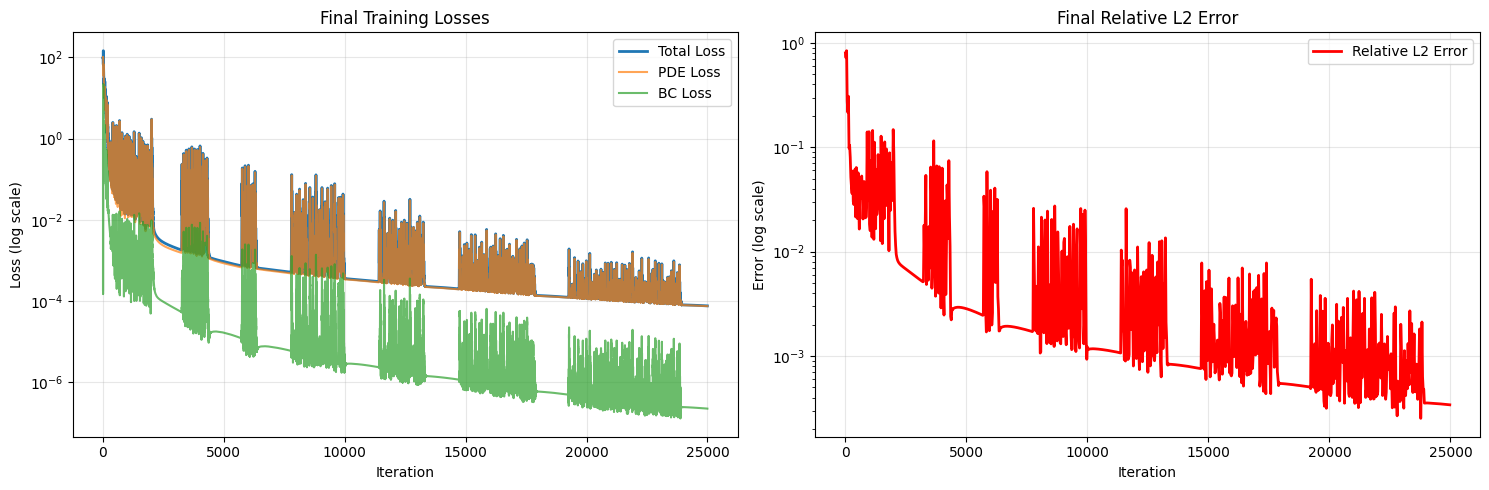

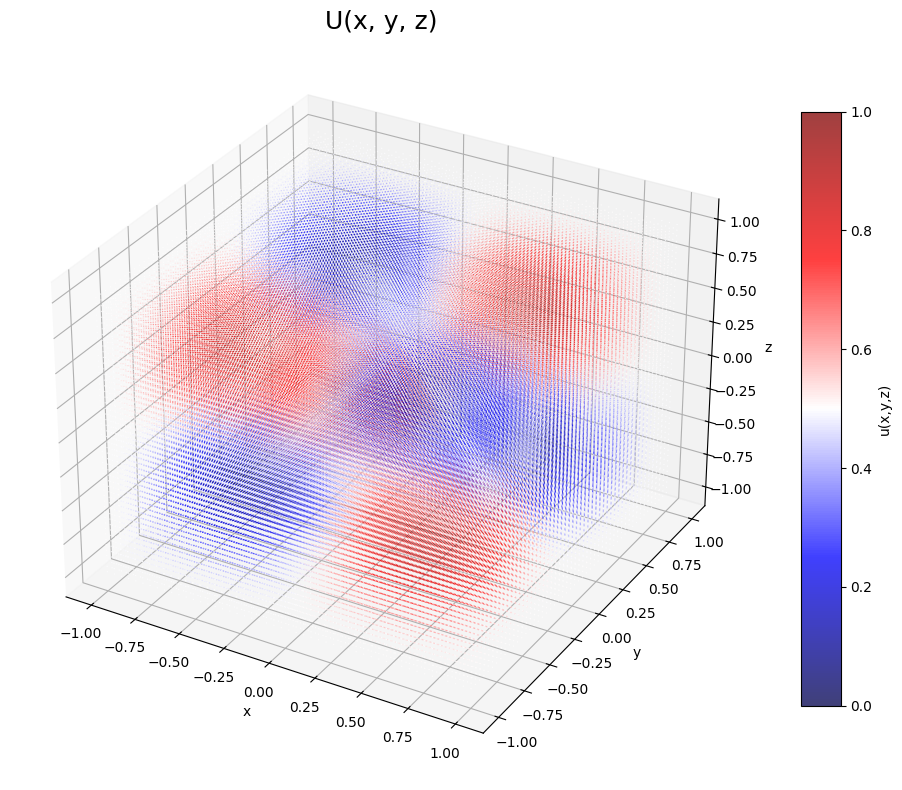

L-BFGS [  1/500] loss=7.7330e-05 | rel_L2=3.21e-04 | best=3.21e-04
L-BFGS [ 10/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 20/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 30/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 40/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 50/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 60/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 70/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 80/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [ 90/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [100/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [110/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [120/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [130/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54e-04
L-BFGS [140/500] loss=7.7091e-05 | rel_L2=2.54e-04 | best=2.54

In [ ]:
history, best_error, best_u = train_spinn(
    model=model,
    optimizer=optimizer,
    x_test=xx_test,
    y_test=yy_test,
    z_test=zz_test,
    u_test=u_test,
    epochs=EPOCHS,
    log_iter=LOG_ITER,
    resample_iter=RESAMPLE_ITER,
    N_per_axis=N_PER_AXIS,
    domain_size=1.0,
    device=device,
    scheduler=scheduler,
    pde_weight=1.0,
    bc_weight=5.0,
)


# Дообучаем так, как это было на семинарх, этот код буквально оттуда


LBFGS_STEPS = 500
pde_weight_lbfgs = 1.0
bc_weight_lbfgs = 10.0  

# Фиксируем коллокационные точки для L-BFGS
xc, yc, zc = make_collocation_grid(N_PER_AXIS, domain_size=1.0, device=device)

def closure():
    optimizer_lbfgs.zero_grad()
    loss_pde, loss_bc = model.calculate_loss(xc, yc, zc)
    loss = pde_weight_lbfgs * loss_pde + bc_weight_lbfgs * loss_bc
    loss.backward()
    return loss

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
)

model.train()
best_lbfgs_error = float('inf')
for step in range(1, LBFGS_STEPS + 1):
    loss = optimizer_lbfgs.step(closure)
    
    if step % 10 == 0 or step == 1:
        with torch.no_grad():
            error, u_pred = compute_error_on_grid(
                model, xx_test, yy_test, zz_test, u_test
            )
        
        if error < best_lbfgs_error:
            best_lbfgs_error = error
            best_u_lbfgs = u_pred.clone()
        
        print(f"L-BFGS [{step:3d}/{LBFGS_STEPS}] "
              f"loss={loss.item():.4e} | "
              f"rel_L2={error.item():.2e} | "
              f"best={best_lbfgs_error:.2e}")


После обучения посчитайте итоговые метрики на тестовой сетке.

> Подбирайте качество за счёт корректной архитектуры, выбора гиперпараметров и настройки обучения, не используя прямую подгонку под тестовую сетку. За такое бан.

In [44]:
model.eval()
with torch.no_grad():
    u_pred_final = model(xx_test[:, 0, 0], yy_test[0, :, 0], zz_test[0, 0, :])

mse = ((u_test.cpu().numpy() - u_pred_final.cpu().numpy()) ** 2).mean()
rel_l2 = relative_l2(u_pred_final, u_test).item()

print(f"MSE: {mse:.2e}")
print(f"Relative L2: {rel_l2:.2e}")

MSE: 7.61e-09
Relative L2: 2.54e-04


In [45]:
score_1_2 = 0.0
if mse <= 5e-3:
    score_1_2 = 0.5 * 1.5
if mse <= 5e-4:
    score_1_2 = 0.6 * 1.5
if mse <= 1e-5:
    score_1_2 = 0.7 * 1.5
if mse <= 1e-7:
    score_1_2 = 0.9 * 1.5
if mse <= 5e-8:
    score_1_2 = 1.0 * 1.5

print(f"Баллы за пункт 1.2: {score_1_2:.2f} / 1.5")

Баллы за пункт 1.2: 1.50 / 1.5


Оценка за пункт 1.2 зависит от наилучшего достигнутого порога по `mse`: каждому порогу соответствует своя доля из **1,5 балла** за качество. Итоговый балл определяется по самому строгому из выполненных условий.

> **Примечание.** Итоговые пороги качества для этой части будут проверяться по метрикам на тестовой сетке. Не забывайте сохранить веса лучшей модели: они понадобятся при сдаче домашнего задания.

In [46]:
torch.save(model.state_dict(), "best_spinn_model.pth")

### Задание 1.3. Краткий анализ (0,5 балла)

После обучения кратко опишите, как вы подбирали конфигурацию модели и что наблюдали в экспериментах.

Можно обсудить:

1. С каких параметров вы начали и к какой конфигурации пришли в итоге.
2. Как изменение `rank` влияло на качество и время обучения.
3. Что сильнее влияло на результат: архитектура body-сетей, плотность коллокационной решётки или баланс между `PDE loss` и `BC loss`.
4. Были ли признаки того, что модель реализована некорректно или обучается неустойчиво, и как вы это диагностировали.



1. я начал с маленького числа точек, ранга, слоев, признаков в слое, все на минималку поставил, обучалось 4 минуты и получил 0,9 скор. Это было норм для такого времени. В итоге я понял, что можно поставить больше точек, и побольше признаков в слое
2. Ранг почти не влияет на скорость(если ставить 4 и 64, то разница в 4 раза(то есть пропорционально корню)) я обучал на 48 и на 8 время работы было почти одинаковое, роялило то сколько у меня еще параллельно файлов выполнялось. При бОльшем ранге, оно больше шумит и хуже сходится, потому что уже переобучается, по крайней мере на моих остальных параметрах. Вот ранга 2 уже сильно не хватает, минимально хочется видеть ранг 4
3. Больше всего влияла плотность решетки, потому что сразу при ней падала скорость обучения и было видно, что мы учимся лучше, на втором месте был балан между PDE и BC
4. Неустойчисвости как таковой не было, все loss-ы шли равномерно без учета всплесков, но их я скидываю на resampling